In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import photon_number
from functions import make_title
import snspd
params = snspd.snspd()

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260414-24496-qcodes.log
Experiment loaded. Last ID no: 472


In [ ]:
wav_range = np.arange(1528e-9, 1535e-9, 1e-9)

Text(0.5, 0, 'Wavelength (nm)')

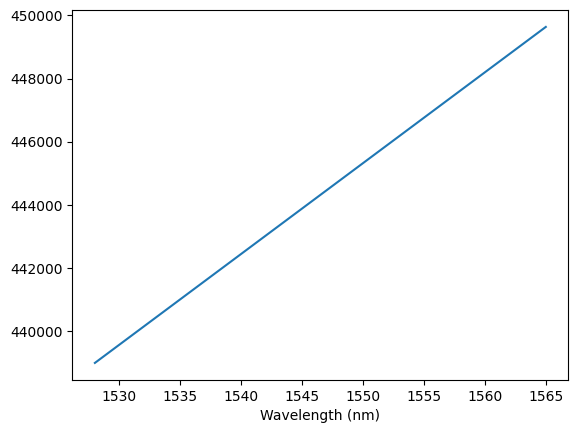

In [25]:
import scipy
import scipy.constants as spc 
v_attenuator = 4.7
wav_range = np.arange(1528e-9, 1565e-9, 1e-9)

ID =  165 # need to update this to read in from new config file
# datasaver.dataset.add_metadata("att_screw_calibration_id", ID)
data = load_by_id(ID).get_parameter_data()
avg_attenuation_screw = np.average(data['attenuation']['attenuation'])

idx = 26 

ID = 459
# datasaver.dataset.add_metadata("att_combined_id", ID)
data = load_by_id(ID).get_parameter_data()
# Extract attenuator voltages 
v_attenuator = data['v_attenuator']['v_attenuator'][idx]
avg_attenuation = data['avg_attenuation']['avg_attenuation'][idx]
avg_power90 = data['avg_power90']['avg_power90'][idx]

total_attenuation=avg_attenuation + avg_attenuation_screw

Nphotons = photon_number(params.bs10, params.bs90, power90=avg_power90, total_attenuation=total_attenuation, wavelength=wav_range)

plt.plot(wav_range*1e9, Nphotons)
plt.xlabel('Wavelength (nm)')

In [29]:
meas = Measurement()
meas.register_custom_parameter("v_attenuator", label="V")
meas.register_custom_parameter("total_attenuation", label="dB")
meas.register_custom_parameter("Nphotons", label="")
meas.register_custom_parameter("wavelength_range", label="nm")

with meas.run() as datasaver: 
    print(datasaver.run_id)

    wavelength_range = np.arange(1528e-9, 1565e-9, 1e-9)
    
    ID =  165 # need to update this to read in from new config file
    # datasaver.dataset.add_metadata("att_screw_calibration_id", ID)
    data = load_by_id(ID).get_parameter_data()
    avg_attenuation_screw = np.average(data['attenuation']['attenuation'])
    
    idx = 26 
    
    ID = 459
    # datasaver.dataset.add_metadata("att_combined_id", ID)
    data = load_by_id(ID).get_parameter_data()
    # Extract attenuator voltages 
    v_attenuator = data['v_attenuator']['v_attenuator'][idx]
    avg_attenuation = data['avg_attenuation']['avg_attenuation'][idx]
    avg_power90 = data['avg_power90']['avg_power90'][idx]
    
    total_attenuation=avg_attenuation + avg_attenuation_screw
    
    Nphotons = photon_number(params.bs10, params.bs90, power90=avg_power90, total_attenuation=total_attenuation, wavelength=wav_range)
    

    # for i in range(len(wavelength_range)): 
    datasaver.add_result(("v_attenuator", v_attenuator),
                     ("total_attenuation", total_attenuation),
                    ("Nphotons", Nphotons),
                    ("wavelength_range", wavelength_range))

Starting experimental run with id: 465. 
465


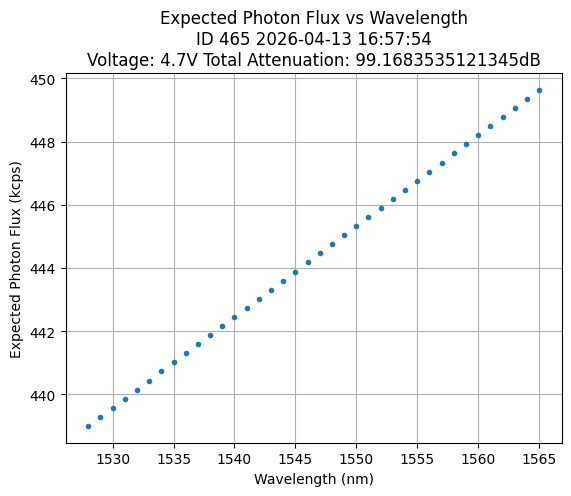

In [5]:
ID = 465
data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator'][0]
total_attenuation = data['total_attenuation']['total_attenuation'][0]
wavelength_range = data['wavelength_range']['wavelength_range']
Nphotons = data['Nphotons']['Nphotons']
title = f'Expected Photon Flux vs Wavelength'
ts = make_title(title, ID, extra=f'Voltage: {v_attenuator}V Total Attenuation: {total_attenuation}dB')
plt.plot(wavelength_range*1e9, Nphotons*1e-3, '.')
plt.title(ts)
plt.ylabel(r'Expected Photon Flux (kcps)')
plt.xlabel('Wavelength (nm)')
plt.grid()

Plaser =  power90/bs90
Pin = Plaser*bs10
Pdevice = Pin*(10**(-total_attenuation/10))

$P_{device}$ is constant, set by laser power and total attenuation in delivery line.

$$ f = \frac{c}{\lambda}$$

$$ E_{photon} = hf$$

$$ \begin{align*}
    N_{photons} & = \frac{P_{device}}{E_{photon}} \\
                & = \frac{P_{device}}{hf} \\
                & = \frac{P_{device}}{h(\frac{c}{\lambda})} \\
                & = \lambda \frac{P_{device}}{hc} \\
    N_{photons} & \propto \lambda \\
    \end{align*}$$
